In [2]:
import pandas as pd

credit_df = pd.read_csv(
    "../data/raw/creditcard.csv"
)

In [3]:
credit_df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
credit_df.shape

(284807, 31)

In [6]:
credit_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
print(credit_df.duplicated().sum())

credit_df.drop_duplicates(inplace=True)

1081


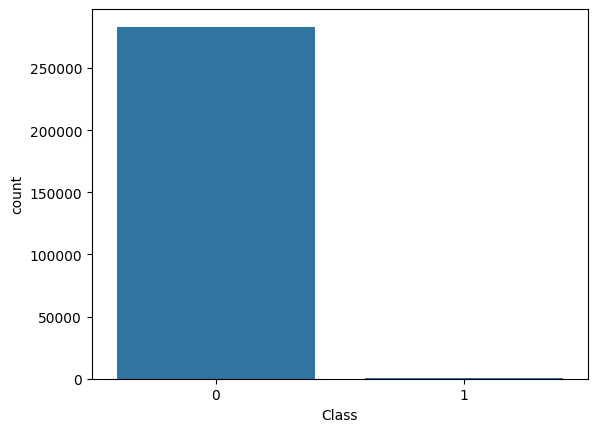

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Class", data=credit_df
)
plt.show()

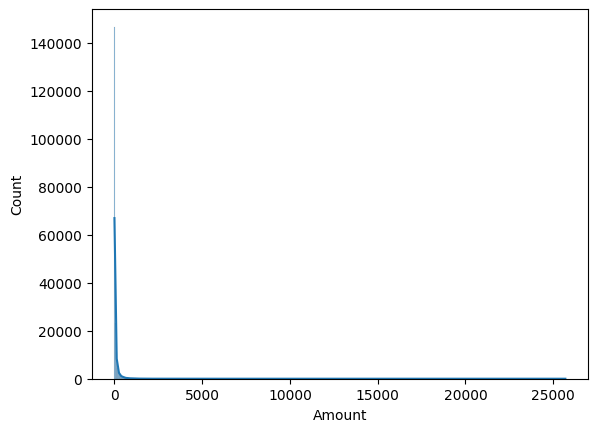

In [5]:
sns.histplot(
    credit_df["Amount"],
    kde=True
)
plt.show()

In [7]:
%pip install scikit-learn

from sklearn.preprocessing import StandardScaler

credit_df["Amount"] = (
    StandardScaler()
    .fit_transform(
        credit_df[["Amount"]]
    )
)

  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.model_selection import train_test_split

X = credit_df.drop("Class", axis=1)
y = credit_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [12]:
%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


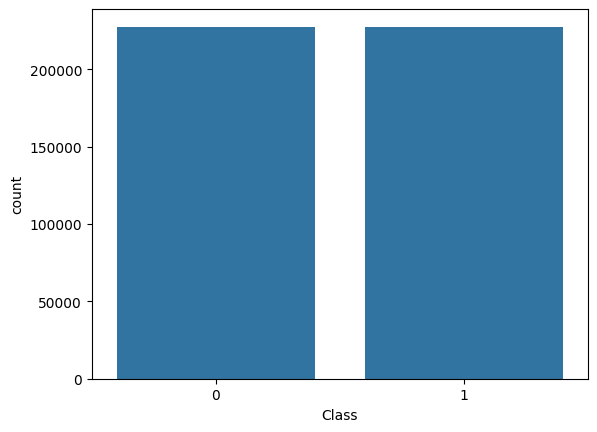

In [14]:
sns.countplot(x=y_train_smote)
plt.show()